In [131]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

#import import dll

In [132]:
df = pd.read_csv("Airline_review.csv")
df.head()

,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended
0,0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,4.0,NaN,NaN,3.0,yes
1,1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,1.0,NaN,NaN,2.0,no
2,2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,1.0,NaN,NaN,2.0,no
3,3,Adria Airways,1,"""I will never fly again with Adria""",28th September 2019,False,Please do a favor yourself and do not fly wi...,NaN,Solo Leisure,Economy Class,Frankfurt to Pristina,September 2019,1.0,1.0,NaN,1.0,NaN,NaN,1.0,no
4,4,Adria Airways,1,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,NaN,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no


In [133]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing per column:\n", df.isna().sum().sort_values(ascending=False).head(20))

if "Recommended" in df.columns:
    print("\nRecommended value counts:\n", df["Recommended"].value_counts(dropna=False))
if "Overall_Rating" in df.columns:
    print("\nOverall_Rating describe:\n", pd.to_numeric(df["Overall_Rating"], errors="coerce").describe())

#EDA liat columns

Shape: (23171, 20)

Dtypes:
 Unnamed: 0                  int64
Airline Name                  str
Overall_Rating                str
Review_Title                  str
Review Date                   str
Verified                     bool
Review                        str
Aircraft                      str
Type Of Traveller             str
Seat Type                     str
Route                         str
Date Flown                    str
Seat Comfort              float64
Cabin Staff Service       float64
Food & Beverages          float64
Ground Service            float64
Inflight Entertainment    float64
Wifi & Connectivity       float64
Value For Money           float64
Recommended                   str
dtype: object

Missing per column:
 Wifi & Connectivity       17251
Aircraft                  16042
Inflight Entertainment    12342
Food & Beverages           8671
Ground Service             4793
Cabin Staff Service        4260
Seat Comfort               4155
Route                      3828

In [134]:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("&", "and")
df.columns

#biar normal karakternya

Index(['Unnamed:_0', 'Airline_Name', 'Overall_Rating', 'Review_Title',
       'Review_Date', 'Verified', 'Review', 'Aircraft', 'Type_Of_Traveller',
       'Seat_Type', 'Route', 'Date_Flown', 'Seat_Comfort',
       'Cabin_Staff_Service', 'Food_and_Beverages', 'Ground_Service',
       'Inflight_Entertainment', 'Wifi_and_Connectivity', 'Value_For_Money',
       'Recommended'],
      dtype='str')

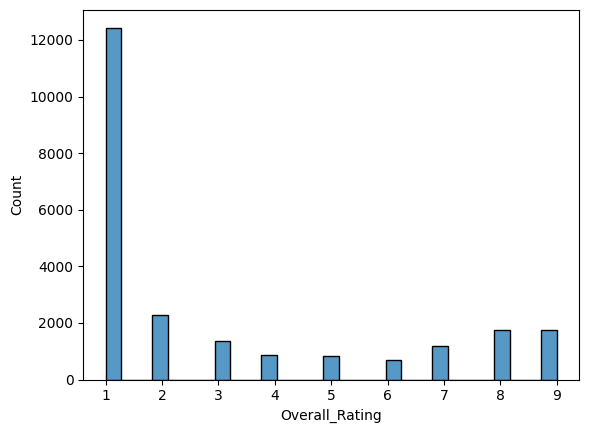

In [135]:
df["Overall_Rating"] = pd.to_numeric(df["Overall_Rating"], errors="coerce")

median_rating = df["Overall_Rating"].median()
df["Overall_Rating"] = df["Overall_Rating"].fillna(median_rating)

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Overall_Rating"])
plt.show()

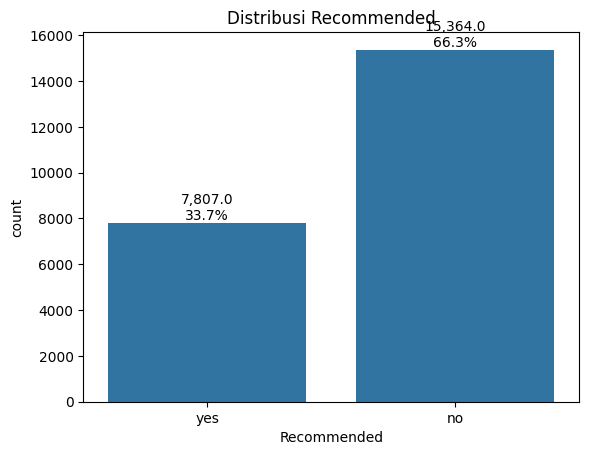

In [136]:
if "Recommended" in df.columns:
    ax = sns.countplot(x="Recommended", data=df)
    total = len(df)
    for p in ax.patches:
        pct = 100 * p.get_height() / total
        ax.annotate(f"{p.get_height():,}\n{pct:.1f}%", (p.get_x()+p.get_width()/2, p.get_height()),
                    ha="center", va="bottom")
    plt.title("Distribusi Recommended")
    plt.show()

#EDA liat target

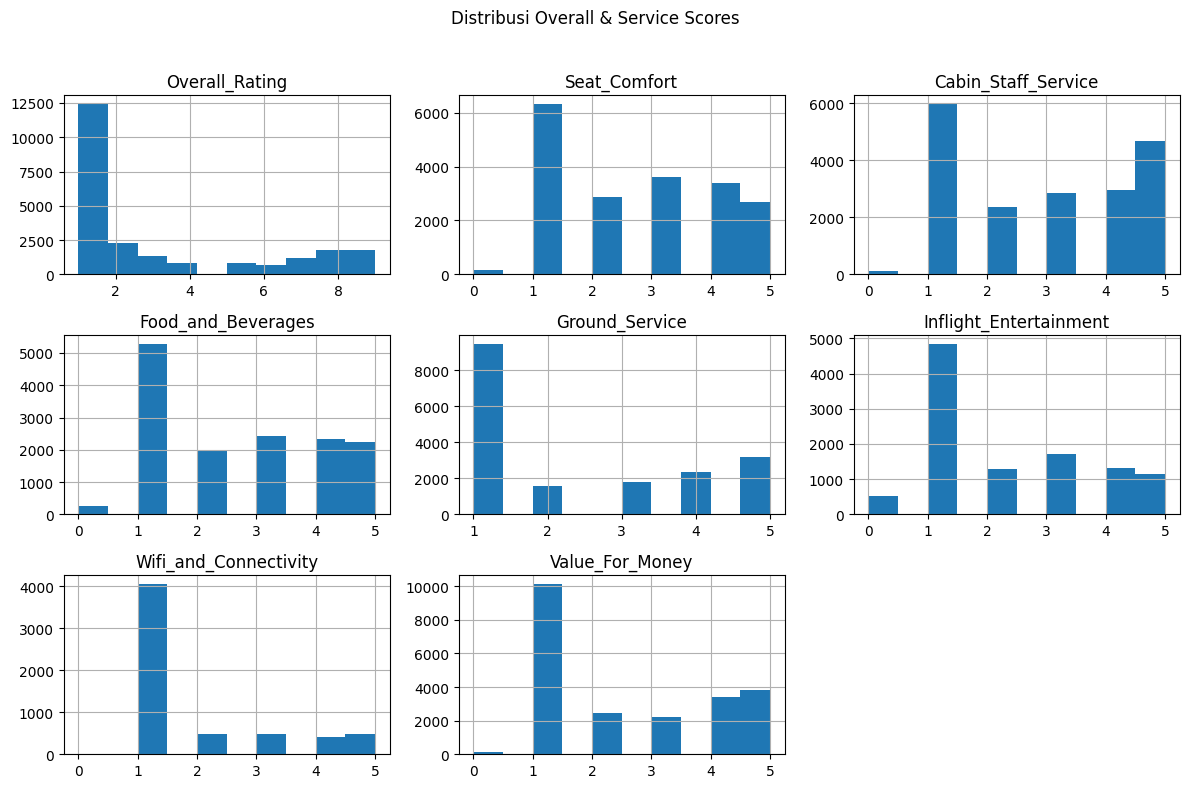

In [137]:
service_cols = [c for c in [
    "Overall_Rating","Seat_Comfort","Cabin_Staff_Service","Food_and_Beverages",
    "Ground_Service","Inflight_Entertainment","Wifi_and_Connectivity","Value_For_Money"
] if c in df.columns]

if service_cols:
    df_num = df[service_cols].apply(pd.to_numeric, errors="coerce")
    df_num.hist(bins=10, figsize=(12, 8))
    plt.suptitle("Distribusi Overall & Service Scores")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

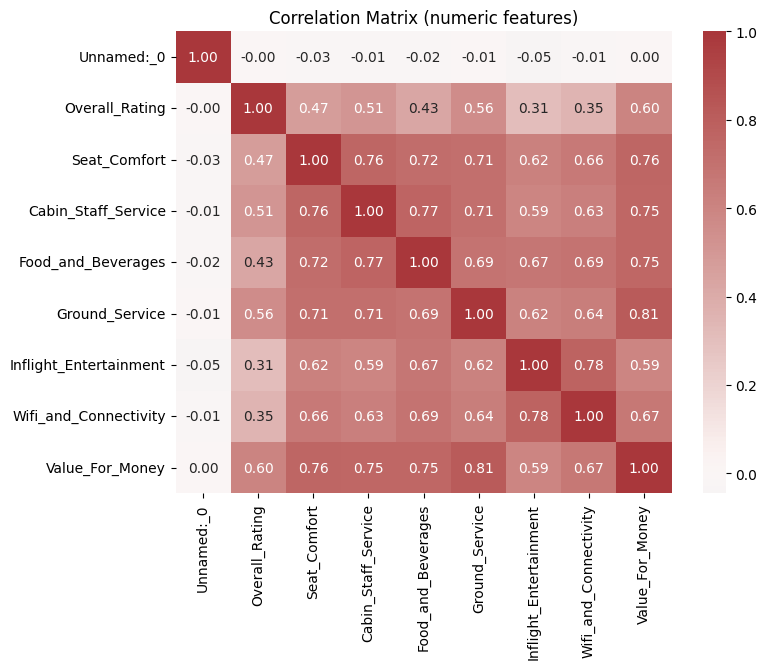

In [138]:
numeric = df.select_dtypes(include=["number"]).columns.tolist()
numeric = [c for c in numeric if c in df.columns]
if numeric:
    corr = df[numeric].apply(pd.to_numeric, errors="coerce").corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
    plt.title("Correlation Matrix (numeric features)")
    plt.show()

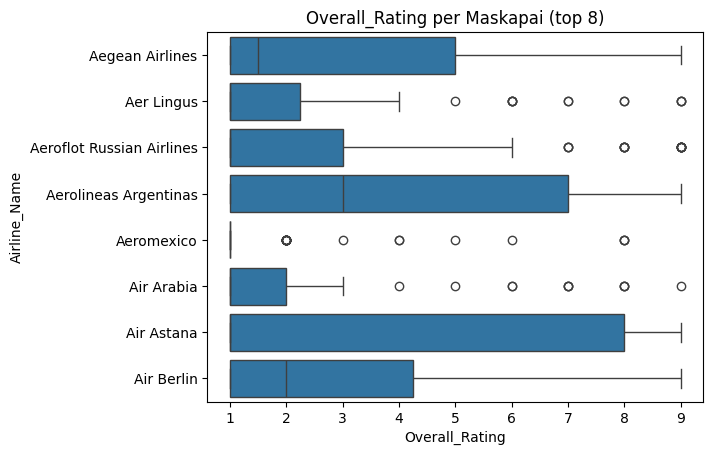

In [139]:
if "Airline_Name" in df.columns and "Overall_Rating" in df.columns:
    top_n = 8
    top_airlines = df["Airline_Name"].value_counts().nlargest(top_n).index.tolist()
    sns.boxplot(y="Airline_Name", x=pd.to_numeric(df["Overall_Rating"], errors="coerce"),
                data=df[df["Airline_Name"].isin(top_airlines)])
    plt.title(f"Overall_Rating per Maskapai (top {top_n})")
    plt.xlabel("Overall_Rating")
    plt.ylabel("Airline_Name")
    plt.show()

Recommended,no,yes
Seat_Comfort,1.840089,3.999708
Cabin_Staff_Service,2.004811,4.396061
Food_and_Beverages,1.656713,3.850852
Ground_Service,1.456827,4.173727
Inflight_Entertainment,1.578194,3.210183
Wifi_and_Connectivity,1.314367,3.384096
Value_For_Money,1.466895,4.260948


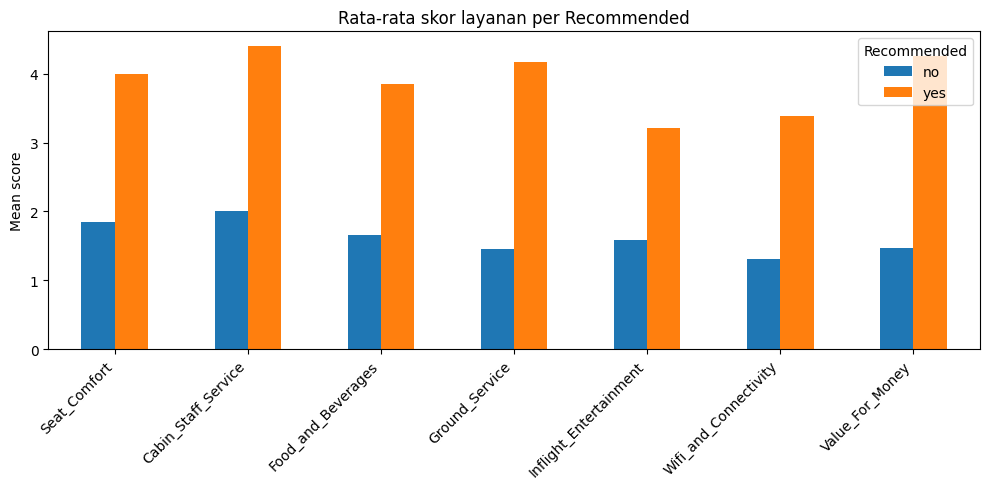

In [140]:
group_cols = [c for c in [
    "Seat_Comfort","Cabin_Staff_Service","Food_and_Beverages",
    "Ground_Service","Inflight_Entertainment","Wifi_and_Connectivity","Value_For_Money"
] if c in df.columns]

if "Recommended" in df.columns and group_cols:
    grp = df.groupby("Recommended")[group_cols].apply(lambda d: d.apply(pd.to_numeric, errors="coerce").mean()).T
    display(grp)
    grp.plot.bar(figsize=(10,5))
    plt.title("Rata-rata skor layanan per Recommended")
    plt.ylabel("Mean score")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [141]:
df["Recommended"] = df["Recommended"].astype(str).str.lower().map({"yes": 1, "no": 0})
df = df[df["Recommended"].isin([0, 1])]
df["Recommended"].value_counts()

#labelling

Recommended
0    15364
1     7807
Name: count, dtype: int64

In [142]:
feature_cols = [
    "Overall_Rating",
    "Seat_Comfort",
    "Cabin_Staff_Service",
    "Food_and_Beverages",
    "Ground_Service",
    "Inflight_Entertainment",
    "Wifi_and_Connectivity",
    "Value_For_Money",
    "Verified",
    "Type_Of_Traveller",
    "Seat_Type",
    "Aircraft",
    "Airline_Name"
]

available_cols = [col for col in feature_cols if col in df.columns]
X = df[available_cols].copy()
y = df["Recommended"]
X.head()

#ambil kolom penting aja, mostly skor" 1-5

,Overall_Rating,Seat_Comfort,Cabin_Staff_Service,Food_and_Beverages,Ground_Service,Inflight_Entertainment,Wifi_and_Connectivity,Value_For_Money,Verified,Type_Of_Traveller,Seat_Type,Aircraft,Airline_Name
0,9.0,4.0,5.0,4.0,4.0,NaN,NaN,3.0,True,Solo Leisure,Economy Class,NaN,AB Aviation
1,1.0,2.0,2.0,1.0,1.0,NaN,NaN,2.0,True,Solo Leisure,Economy Class,E120,AB Aviation
2,1.0,2.0,1.0,1.0,1.0,NaN,NaN,2.0,True,Solo Leisure,Economy Class,Embraer E120,AB Aviation
3,1.0,1.0,1.0,NaN,1.0,NaN,NaN,1.0,False,Solo Leisure,Economy Class,NaN,Adria Airways
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,True,Couple Leisure,Economy Class,NaN,Adria Airways


In [143]:
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = X[col].fillna("Unknown")
    else:
        X[col] = pd.to_numeric(X[col], errors="coerce")

if "Verified" in X.columns:
    X["Verified"] = X["Verified"].astype(int)

#preprocessing lagi, verified biar jadi int, tros isi yang kosong jdi unknown

In [144]:
numeric_cols = [
    'Overall_Rating', 'Seat_Comfort', 'Cabin_Staff_Service', 
    'Food_and_Beverages', 'Ground_Service', 'Inflight_Entertainment', 
    'Wifi_and_Connectivity', 'Value_For_Money'
]

for col in numeric_cols:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

if "Verified" in X.columns:
    X["Verified"] = X["Verified"].astype(int)
    numeric_cols.append("Verified")

categorical_cols = [col for col in X.columns if col not in numeric_cols]

numeric_features = numeric_cols
categorical_features = categorical_cols

In [145]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

#transformers

In [146]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((18536, 13), (4635, 13))

In [147]:
logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logreg_model.fit(X_train, y_train)
y_pred = logreg_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#tests

Accuracy: 0.9454153182308522
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      3073
           1       0.92      0.91      0.92      1562

    accuracy                           0.95      4635
   macro avg       0.94      0.94      0.94      4635
weighted avg       0.95      0.95      0.95      4635



c:\Users\Reagan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['Type_Of_Traveller' 'Seat_Type' 'Airline_Name']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
c:\Users\Reagan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['Type_Of_Traveller' 'Seat_Type' 'Airline_Name']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


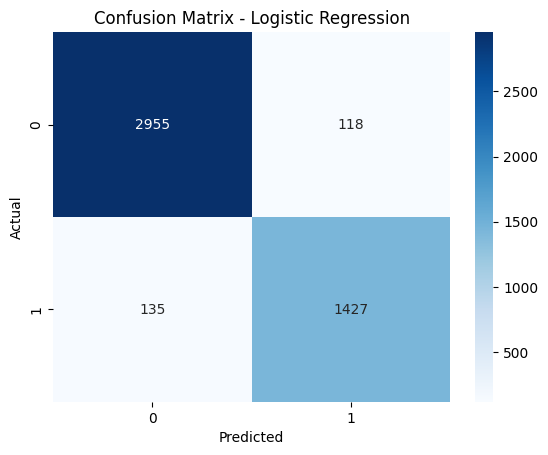

In [148]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [149]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

c:\Users\Reagan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['Type_Of_Traveller' 'Seat_Type' 'Airline_Name']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


Accuracy: 0.9594390507011866
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3073
           1       0.94      0.94      0.94      1562

    accuracy                           0.96      4635
   macro avg       0.95      0.95      0.95      4635
weighted avg       0.96      0.96      0.96      4635



c:\Users\Reagan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['Type_Of_Traveller' 'Seat_Type' 'Airline_Name']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


In [150]:
final_model = rf_model

In [151]:
df["predicted_recommended"] = final_model.predict(X)
df["predicted_recommended_prob"] = final_model.predict_proba(X)[:, 1]
df[["Overall_Rating", "Recommended", "predicted_recommended", "predicted_recommended_prob"]].head()

c:\Users\Reagan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['Type_Of_Traveller' 'Seat_Type' 'Airline_Name']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
c:\Users\Reagan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['Type_Of_Traveller' 'Seat_Type' 'Airline_Name']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


,Overall_Rating,Recommended,predicted_recommended,predicted_recommended_prob
0,9.0,1,1,1.0
1,1.0,0,0,0.0
2,1.0,0,0,0.0
3,1.0,0,0,0.0
4,1.0,0,0,0.0


In [152]:
service_cols = [
    c for c in [
        "Seat_Comfort",
        "Cabin_Staff_Service",
        "Food_and_Beverages",
        "Ground_Service",
        "Inflight_Entertainment",
        "Wifi_and_Connectivity",
        "Value_For_Money"
    ] if c in df.columns
]

df["service_issue_score"] = df[service_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)

def classify_issue(row):
    rating = row["Overall_Rating"] if pd.notna(row["Overall_Rating"]) else np.nan
    issue_score = row["service_issue_score"]
    if pd.isna(rating) or pd.isna(issue_score):
        return "Unknown"
    if rating >= 7 and issue_score >= 3:
        return "Solveable"
    if rating <= 4 and issue_score <= 2:
        return "Non-solveable"
    return "Mixed / Review Needed"

df["Overall_Rating"] = pd.to_numeric(df["Overall_Rating"], errors="coerce")
df["service_issue_score"] = pd.to_numeric(df["service_issue_score"], errors="coerce")
df["issue_class"] = df.apply(classify_issue, axis=1)
df["issue_class"].value_counts(dropna=False)

issue_class
Non-solveable            11101
Mixed / Review Needed     6585
Solveable                 4419
Unknown                   1066
Name: count, dtype: int64

In [153]:
def priority_matrix(row):
    rating = row["Overall_Rating"]
    issue_score = row["service_issue_score"]

    if pd.isna(rating) or pd.isna(issue_score):
        return "Unknown"

    if issue_score >= 4 and rating <= 4:
        return "Hard + Important"
    if issue_score >= 4 and rating > 4:
        return "Easy + Important"
    if issue_score < 4 and rating <= 4:
        return "Hard + Not Important"
    return "Easy + Not Important"

df["priority_class"] = df.apply(priority_matrix, axis=1)
df["priority_class"].value_counts()

priority_class
Hard + Not Important    13851
Easy + Important         3080
Easy + Not Important     3003
Hard + Important         2171
Unknown                  1066
Name: count, dtype: int64

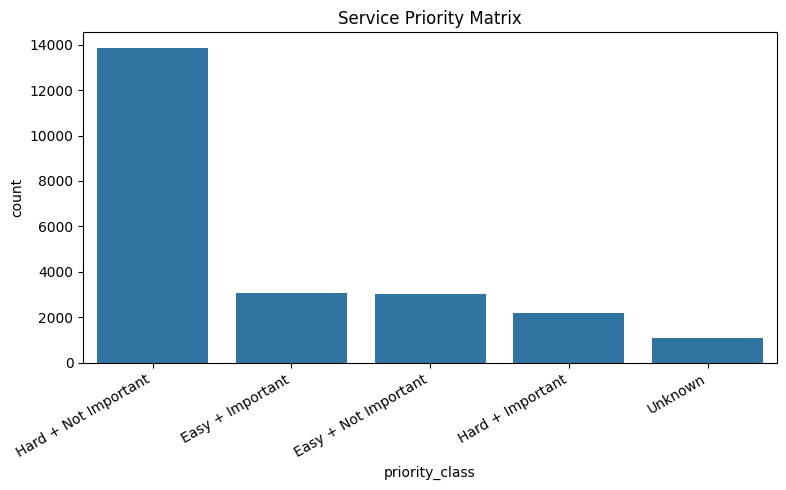

In [154]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="priority_class", order=df["priority_class"].value_counts().index)
plt.xticks(rotation=30, ha="right")
plt.title("Service Priority Matrix")
plt.tight_layout()
plt.show()

In [155]:
if hasattr(final_model.named_steps["classifier"], "feature_importances_"):
    classifier = final_model.named_steps["classifier"]
    pre = final_model.named_steps["preprocessor"]

    if categorical_features:
        cat_encoder = pre.named_transformers_["cat"].named_steps["onehot"]
        cat_feature_names = cat_encoder.get_feature_names_out()
    else:
        cat_feature_names = np.array([])

    feature_names = np.r_[numeric_features, cat_feature_names]
    importances = classifier.feature_importances_

    n = min(len(feature_names), len(importances))
    feature_importance = pd.DataFrame({
        "feature": feature_names[:n],
        "importance": importances[:n]
    }).sort_values("importance", ascending=False)

    feature_importance.head(15)

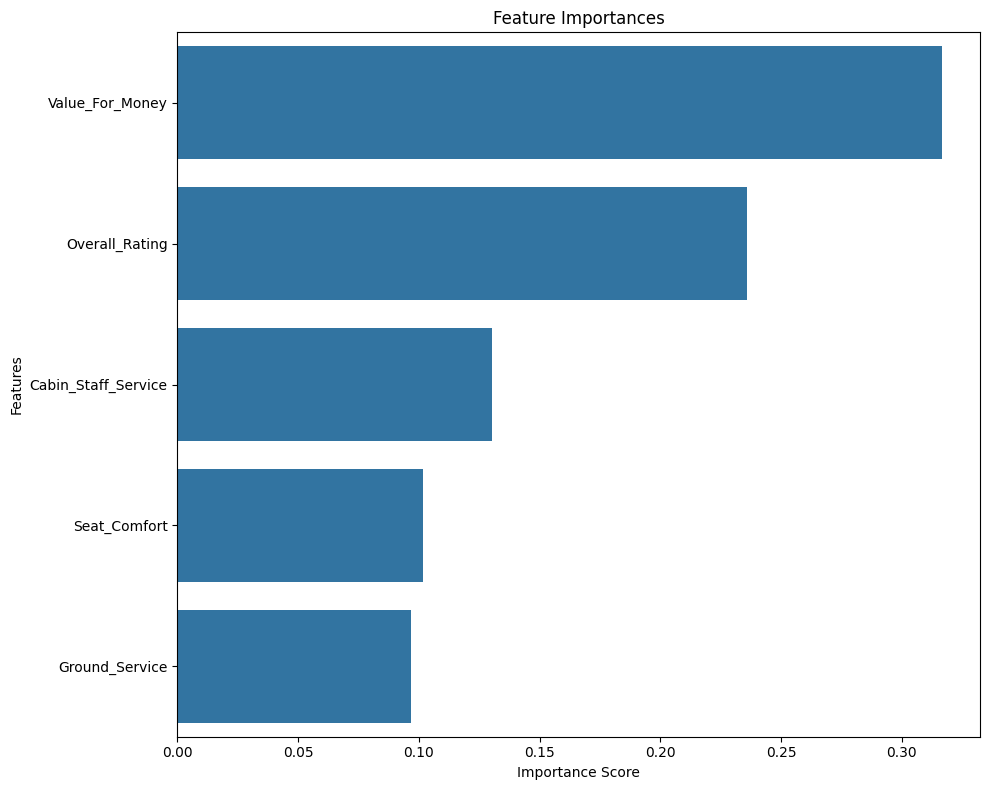

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = feature_importance.sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(5),
    x="importance", 
    y="feature"
)

plt.title("Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()

plt.show()

c:\Users\Reagan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['Type_Of_Traveller' 'Seat_Type' 'Airline_Name']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


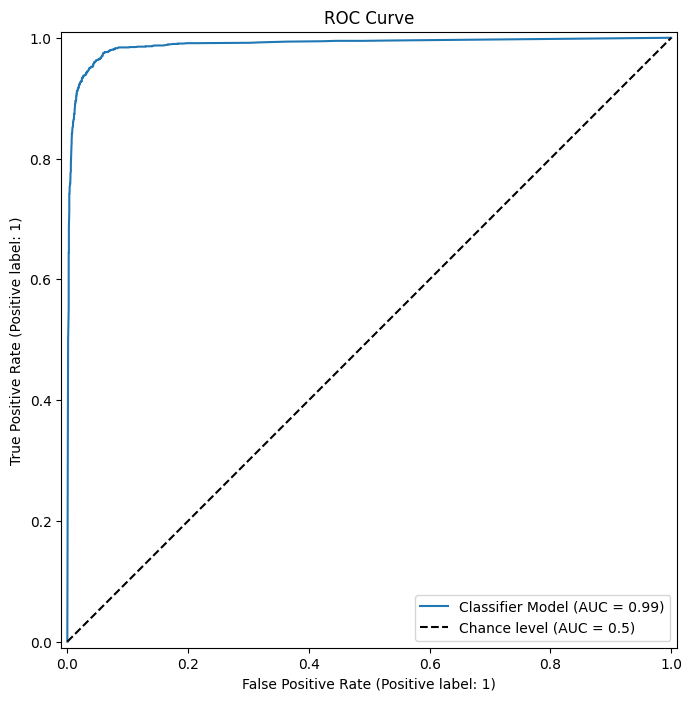

In [161]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

RocCurveDisplay.from_estimator(
    final_model, 
    X_test, 
    y_test, 
    ax=ax, 
    plot_chance_level=True,
    name="Classifier Model"
)

plt.title("ROC Curve")
plt.show()

In [ ]:
summary = df["priority_class"].value_counts(dropna=False)
summary

priority_class
Hard + Not Important    13851
Easy + Important         3080
Easy + Not Important     3003
Hard + Important         2171
Unknown                  1066
Name: count, dtype: int64